In [46]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from scipy.signal import find_peaks, welch
from lib.readwav import *

In [ ]:

%matplotlib widget
plt.close('all')

# NO


questo codice funziona benissimo per segnali con frequenze molto altre (sopra i 500Hz va che è una meraviglia)

ahimè, tra tutti i file .wav ce ne sono alcuni che hanno frequenze sui 100Hz o 200Hz e in questi casi il codice non riesce ad identificare correttamente le frequenze in generale.

esempi di buon funzionamento: note_1.wav, note_104.wav, note_2.wav

esempi di cattivo funzionamento: note_72.wav, note_238.wav

per i file per cui non va bene è perchè a frequenza bassa hanno periodo maggiore, quindi nel fare l'averging taglio fuori qualcosa di troppo, quindi aumentando funziona.
Per automattizzare questa selezione si potrebbe calcolare preventivamente il periodo del segnale e scegliere la dimensione della finestra in base a questo, in modo da avere sempre un numero sufficiente di periodi all'interno di ogni finestra.

In [110]:
# leggiamo un singolo file audio
rate, note = readwav('./wav_files/note_25.wav')

In [111]:
#togliamo il primo 25% del segnale e l'ultimo 10% e plotto mantenendo i secondi corretti
note = note[:, 0] # prendo solo un canale se il segnale è stereo

start = int(len(note) * 0.25)
end = int(len(note) * 0.9)
note = note[start:end]
time = np.arange(len(note)) / rate

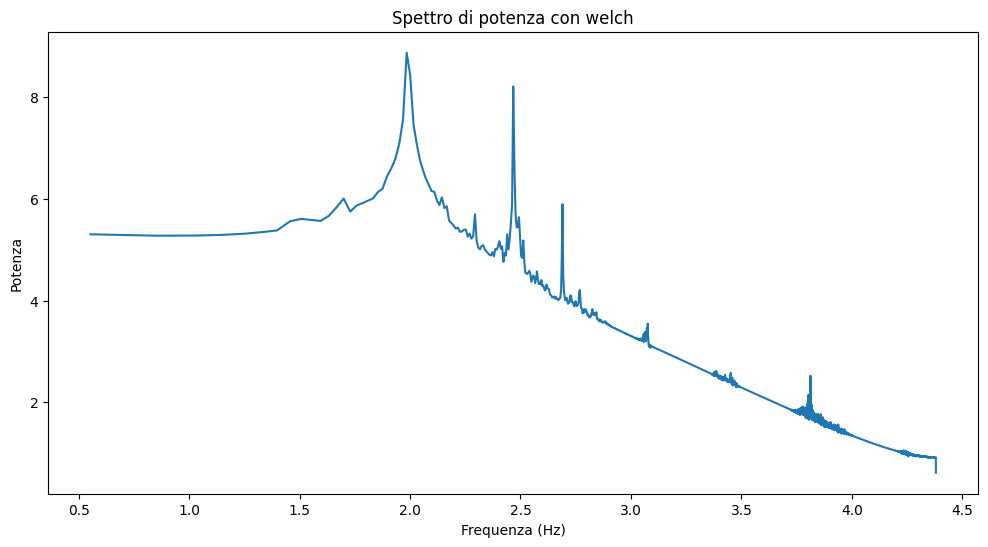

In [112]:
sigma = 10000

gaussian_window = scipy.signal.windows.gaussian(len(note)//15, std=sigma)

frequencies, spectrum = welch(note, fs=rate, nperseg=len(gaussian_window), window=gaussian_window)

log_frequencies = np.log10(frequencies[1:])
log_spectrum = np.log10(spectrum[1:])

plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.title('Spettro di potenza con welch')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.show()

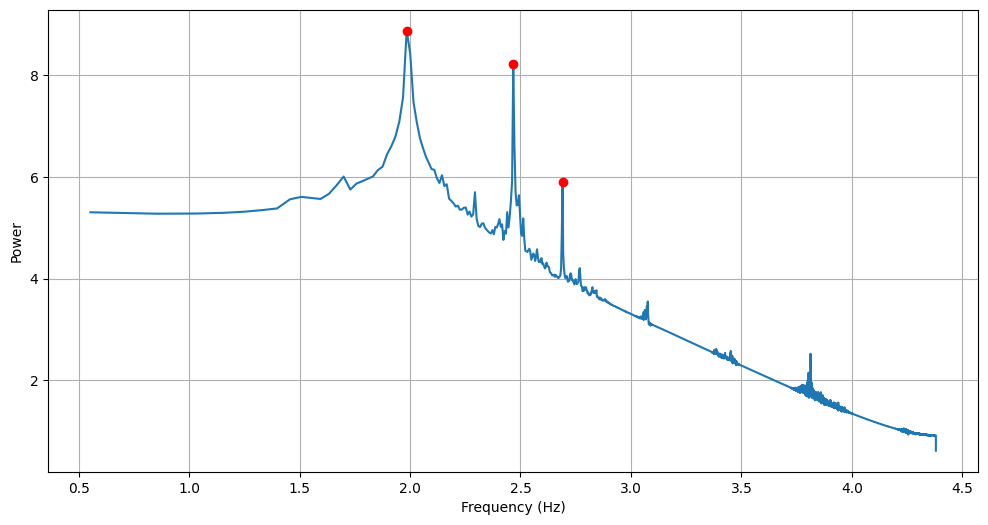

In [113]:
prom = 1
peaks, _ = find_peaks(log_spectrum, prominence=prom)


# segnamole sul grafico
plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.plot(log_frequencies[peaks], log_spectrum[peaks], 'ro')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
#plt.title('Average Power Spectrum with Gaussian Windowing and Peaks')
plt.grid()
plt.show()

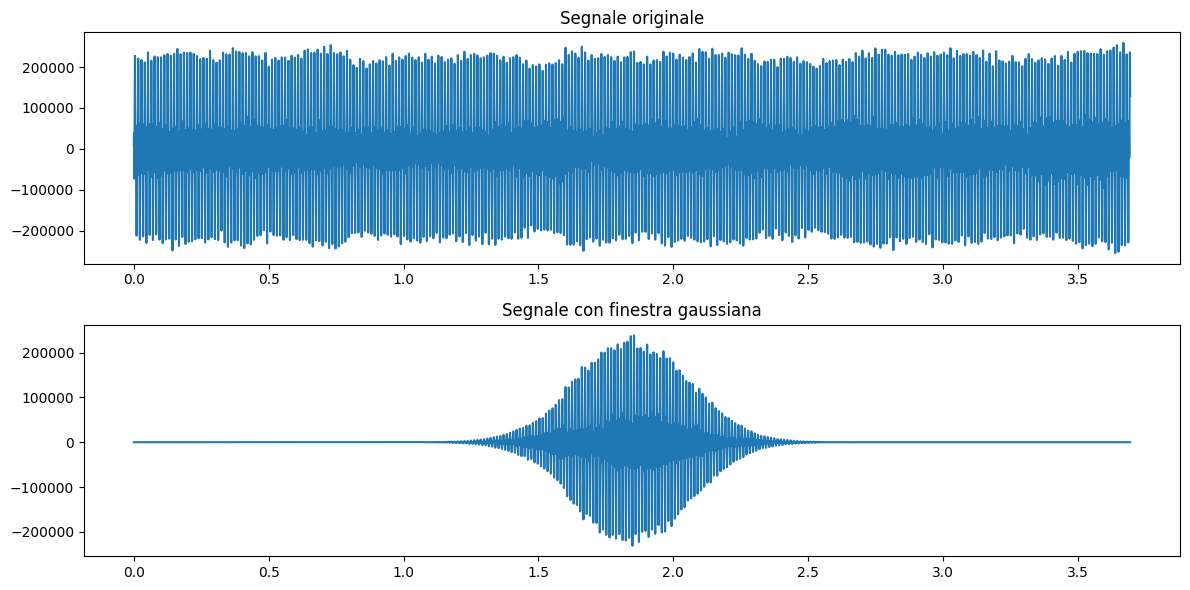

In [37]:
# Implementiamo la finestra gaussiana da applicare al segnale, in modo da attenure l'attacco e il decadimento
def gaussian_window(signal, sigma):
    n = signal.shape[0]
    x = np.arange(n)
    center = 0.5 * n
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    return signal * window


# applichiamo la finestra gaussiana al segnale  (sigma deve dipendere da tempo finestra)
sigma = 10000  # puoi regolare questo parametro per ottenere l'effetto desiderato
note_windowed = gaussian_window(note, sigma)

# visualizzo segnale originale e sotto segnale con fnestra gaussiana
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, note)
plt.title('Segnale originale')
plt.subplot(2, 1, 2)
plt.plot(time, note_windowed)
plt.title('Segnale con finestra gaussiana')
plt.tight_layout()
plt.show()


In [38]:
# un periodo è la distanza tra due massimi alti uguali
# quindi prendo una parte centrale del segnale, calcolo il massimo e prendo la distanza tra i massimi

#taglio segnale al centro
center_start = int(len(note) * 0.58)
center_end = int(len(note) * 0.62)
note_center = note[center_start:center_end]

#trovo massimo. poi tiro una linea e tutte le intersezioni con la linea sono i periodi
threshold = 0.9 * np.max(note_center) # soglia per trovare i massimi
peaks, _ = find_peaks(note_center, height=threshold)
periods = np.diff(peaks) / rate # distanza tra i massimi in secondi
fundamental_freq = 1 / np.mean(periods) # frequenza fondamentale in Hz
print(f'Frequenza fondamentale stimata: {fundamental_freq:.2f} Hz')



Frequenza fondamentale stimata: 103.40 Hz


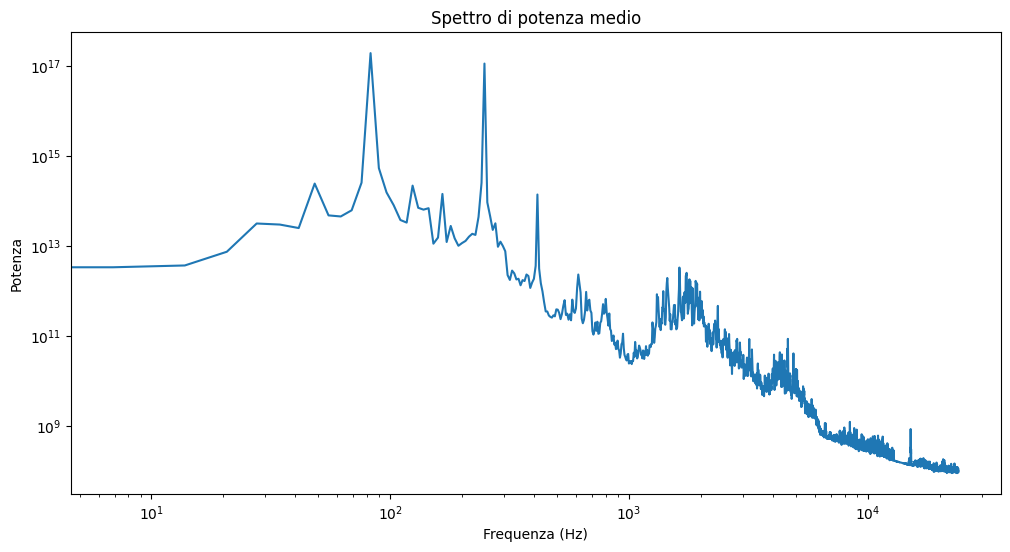

In [ ]:
# ora calcoliamo la dimensione della finestra in modo da avere almeno N periodi al suo interno, in modo da avere una buona risoluzione in frequenza
N = 15 # numero di periodi da includere nella finestra
durata_finestra = N * (1 / fundamental_freq) # durata della finestra in secondi
window_size = int(durata_finestra * rate) # dimensione della finestra
if (window_size < 2048):
    window_size = 2048 # se la finestra è più grande del segnale, la riduco alla dimensione del segnale
hop_size = window_size // 3     # passo di sovrapposizione
num_windows = (len(note) - window_size) // hop_size + 1

power_spectra= []
for i in range(num_windows):
    start = i * hop_size
    end = start + window_size
    segment = note[start:end]
    
    # Applico la finestra gaussiana al segmento
    segment_windowed = gaussian_window(segment, 10000)
    
    # Calcolo la rfft e poi la sua potenza (modulo quadro)
    spectrum = np.fft.rfft(segment_windowed)
    power_spectrum_prev = np.abs(spectrum) ** 2
    power_spectra.append(power_spectrum_prev)

# Sommo tutti questi spettri di potenza e divido per il numero di segmenti
average_power_spectrum = np.mean(power_spectra, axis=0)
frequencies = np.fft.rfftfreq(window_size, d=1/rate)

# visualizzo lo spettro di potenza medio
plt.figure(figsize=(12, 6))
plt.loglog(frequencies, average_power_spectrum)
plt.title('Spettro di potenza medio')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.show()




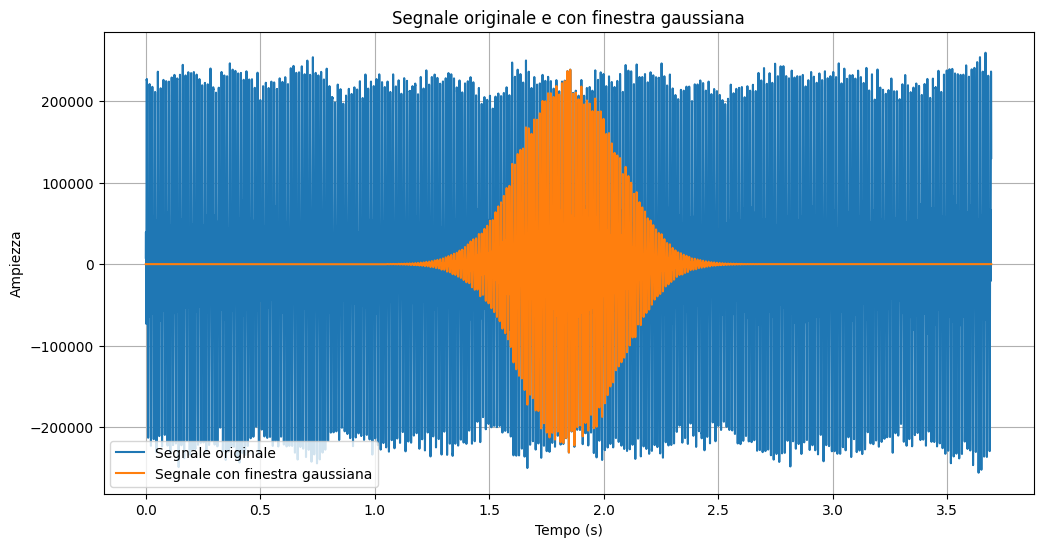

In [40]:
gaussian_window_full = gaussian_window(note, 10000)
plt.figure(figsize=(12, 6))
plt.plot(time, note, label='Segnale originale')
plt.plot(time, gaussian_window_full, label='Segnale con finestra gaussiana')
plt.title('Segnale originale e con finestra gaussiana')
plt.xlabel('Tempo (s)')
plt.ylabel('Ampiezza')
plt.legend()
plt.grid()
plt.show()

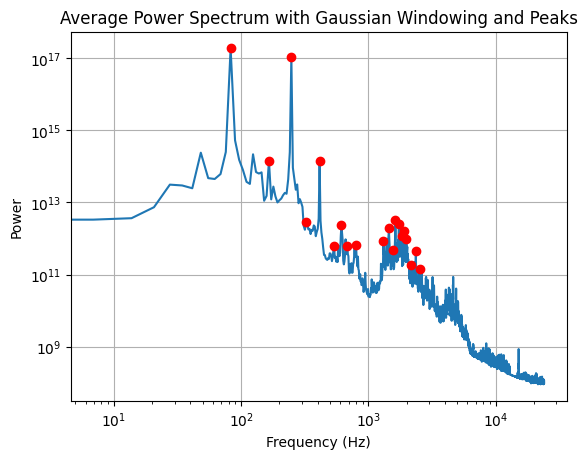

In [ ]:
# troviamo i picchi nello spettro di potenza medio
prom = np.max(average_power_spectrum) * 0.1
# Calcola la risoluzione spettrale (quanti Hz ci sono tra un indice e l'altro dell'array)
df = frequencies[1] - frequencies[0]

# Vogliamo che la distanza minima sia circa il 70% della frequenza fondamentale
# espressa in INDICI dell'array.
distanza_indici = int((fundamental_freq * 0.7) / df)

# Se distanza_indici viene minore di 1, find_peaks da errore, quindi:
distanza_indici = max(1, distanza_indici)
corrected_peaks, _ = find_peaks(average_power_spectrum, prominence = prom, distance=distanza_indici)

if len(corrected_peaks) < 6:
    prom = 10**(np.floor(np.log10(average_power_spectrum[0]))-1)
    corrected_peaks, _ = find_peaks(average_power_spectrum, prominence = prom, distance=distanza_indici)
#peaks, _ = find_peaks(average_power_spectrum, prominence= prom)  # ad esempio, consideriamo picchi che superano il 10% del massimo


# segnamole sul grafico
plt.figure()
plt.loglog(frequencies, average_power_spectrum)
plt.plot(frequencies[corrected_peaks], average_power_spectrum[corrected_peaks], 'ro')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Average Power Spectrum with Gaussian Windowing and Peaks')
plt.grid()
plt.show()

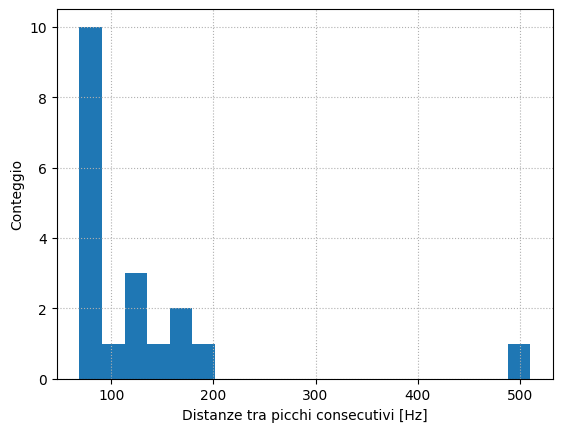


Il bin 1 (su 20) è quello con più istanze, ossia 10

Stima finale della fondamentale: 79 +- 6.3e+00 Hz



In [42]:
# Ora contiamo le istanze di multipli di armoniche fondamentali, nel senso che calcoliamo le distanze tra un picco e l'altro
# e queste in teoria sono multipli interi dell'armonica fondamentale. Queste distanze dovrebbero poi in teoria accumularsi sul valore
# giusto della fondamentale. Purtroppo spesso i dati sono troppo pochi per fare test migliori.
peak_frequencies = frequencies[corrected_peaks]
peaks_distances = np.diff(peak_frequencies)

plt.figure()
plt.hist(peaks_distances, bins=20) # La scelta di 20 bin è arbitraria
plt.xlabel("Distanze tra picchi consecutivi [Hz]")
plt.ylabel("Conteggio")
plt.grid(linestyle = ":")
plt.show()

counts, bin_edges = np.histogram(peaks_distances, bins=20) # Replichiamo i dati dell'istogramma
index_max = np.argmax(counts)
print("\nIl bin", index_max+1, "(su 20) è quello con più istanze, ossia", counts[index_max])
# Presumiamo il bin più alto sia banalmente la fondamentale

# Per arrivare a un risultato chiuso, calcoliamo la media dei picchi all'interno del bin più alto:
distances_in_bin = peaks_distances[(peaks_distances >= bin_edges[index_max]) & (peaks_distances <= bin_edges[index_max + 1])]
fundamental = np.mean(distances_in_bin)
dev = np.std(distances_in_bin)
print("\nStima finale della fondamentale: {:.0f} +- {:.1e} Hz\n".format(fundamental, dev))

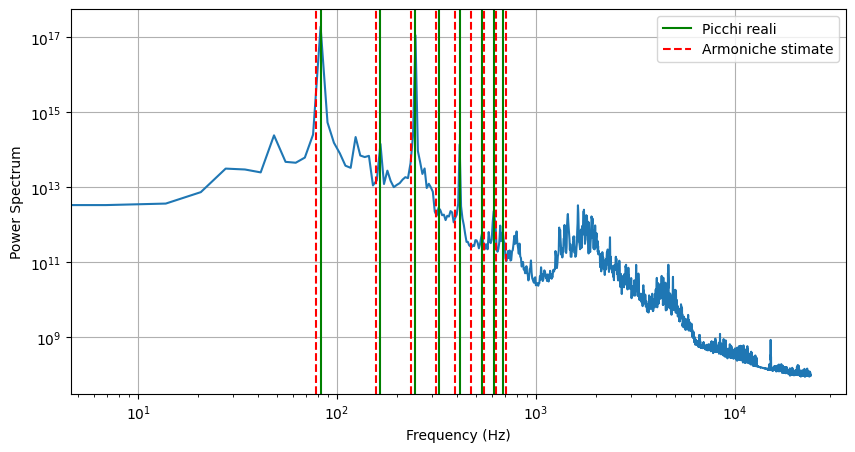

In [43]:
# dalla fondamentale calcolo le armoniche successive 
harmonics_estimate = [fundamental * i for i in range(1, 10)]

# ora voglio vedere se queste armoniche stimate sono vicine ai picchi che ho trovato prima
# in modo da salvare le armoniche reali presenti nel segnale
harmonics_array = []
harmonics_real = []
tolerance_harmonics = 30  # in Hz
for h in harmonics_estimate:
    found = False
    for f in peak_frequencies[:20]:
        if abs(f - h) < tolerance_harmonics:
            harmonics_real.append(f)
            harmonics_array.append(f)
            found = True
            break
    if not found:
        harmonics_array.append(h)
        harmonics_real.append(None)

# visualizzo le armoniche stimate e quelle reali sul grafico
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.grid()
# Solo valori validi (non None) per le armoniche reali
for f in harmonics_real[:20]:  
    if f is not None:
        plt.axvline(f, color='g', linestyle='-', label='Picchi reali' if f == harmonics_real[0] else "")
for h in harmonics_estimate:
    plt.axvline(h, color='r', linestyle='--', label='Armoniche stimate' if h == harmonics_estimate[0] else "")
plt.legend()
plt.show()

In [44]:
n_armoniche = 6
harmonics_power_spectrum = []

# salvo i valori di power spectrum per le armoniche stimati
# in pratica per ogni armonica salvo il valore del power spectrum della frequenza che sto considerando
# se ho una armonica molto vicina a quella stimata, prendo il valore del power spectrum di quella frequenza, altrimenti prendo il valore del power spectrum alla frequenza stimata (quindi il rumore di fondo)
# uso l'array con tutte le frequenze (harmonics_array) 

intorno = 5 

for i in range(n_armoniche):
    f_target = harmonics_array[i]
    
    idx_target = np.argmin(np.abs(frequencies - f_target))
    
    start = max(0, idx_target - intorno)
    end = min(len(average_power_spectrum), idx_target + intorno + 1)
    
    valore_potenza = np.max(average_power_spectrum[start:end])
    harmonics_power_spectrum.append(valore_potenza)
    
# Normalizzazione per il K-means
# Dividiamo tutto per la potenza della fondamentale (il primo elemento)
#A1 = harmonics_power_spectrum[0]
#harmonics_normalizzati = [p / A1 for p in harmonics_power_spectrum]

# Verifichiamo cosa abbiamo ottenuto
for i in range(n_armoniche):
    print(f"Armonica {i+1}: {harmonics_array[i]:.2f} Hz | Potenza Relativa: {harmonics_power_spectrum[i]:.2e}")

Armonica 1: 82.73 Hz | Potenza Relativa: 1.88e+17
Armonica 2: 165.47 Hz | Potenza Relativa: 1.41e+14
Armonica 3: 248.20 Hz | Potenza Relativa: 1.10e+17
Armonica 4: 324.04 Hz | Potenza Relativa: 1.23e+13
Armonica 5: 413.67 Hz | Potenza Relativa: 1.37e+14
Armonica 6: 471.59 Hz | Potenza Relativa: 9.75e+11


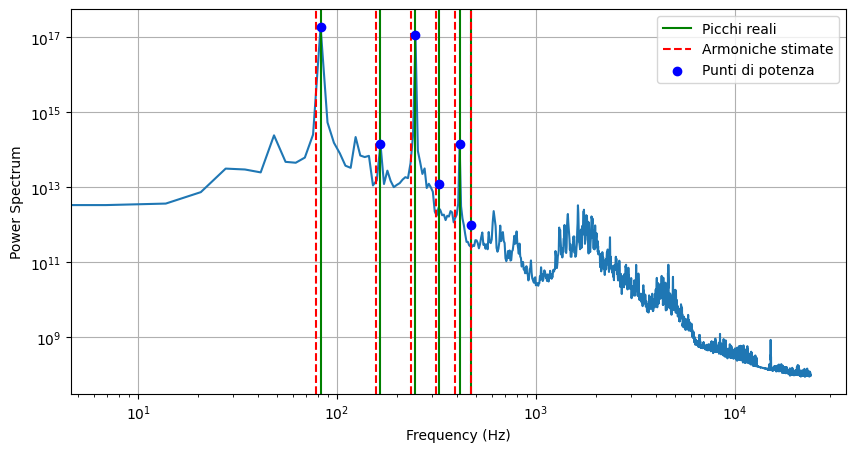

In [45]:
# voglio vedere i punti di power spectrum in corrispondenza delle frequenze che mi trova
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.grid()
for i in range(n_armoniche):
    f = harmonics_array[i]
    if f is not None:
        plt.axvline(f, color='g', linestyle='-', label='Picchi reali' if i == 0 else "")
    h = harmonics_estimate[i]
    plt.axvline(h, color='r', linestyle='--', label='Armoniche stimate' if i == 0 else "")
    plt.scatter(f, harmonics_power_spectrum[i], color='blue', zorder=5, label='Punti di potenza' if i == 0 else "")
plt.legend()
plt.show()